## Iterative Workflow Inifine

In [15]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

In [3]:
class SimpleIterativeWorkflow(TypedDict):
    poem : str
    feedback :str


In [11]:
def generator_node(state: SimpleIterativeWorkflow) -> SimpleIterativeWorkflow:
    print("Generator Working.....")
    if not state.get("feedback"):
        return {"poem": "AI is very Cool"}  
    else:
        return {"poem": "AI is Cool"}
    
def conditional_edges(state: SimpleIterativeWorkflow) -> Literal["retry", "finish"]:
    count = len(state["poem"].split())

    if count == 3:
        return "finish"
    else:
        return "retry"

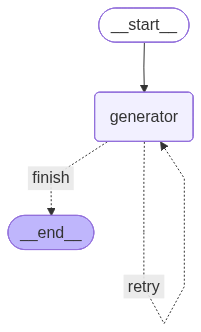

In [12]:
builder = StateGraph(SimpleIterativeWorkflow)

builder.add_node("generator", generator_node)
builder.add_edge(START, "generator")

builder.add_conditional_edges("generator", conditional_edges, {
    "retry": "generator", "finish": END
})
graph = builder.compile()
graph


## Complex Example of Iterative Workflow with Reducers and Multi-Model

In [17]:
import operator
from typing_extensions import TypedDict
from typing import TypedDict, Literal, List, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field

In [18]:
# Pydrantic Schemas

class DraftOutput(BaseModel):
    title: str = Field(description="The catchy title of the poem")
    content: str = Field(description= "The full body of the report")
    word_count: int = Field(description="The number of words in the poem")

class CritiqueOutput(BaseModel):
    feedback: int = Field(description="Score from 1-10", ge=1, le=10)
    improvements : List[str] = Field(description="A list of improvements that can be made to the poem")
    is_finished : bool = Field(description="True only if score is 9 or 10")



In [54]:
class IterativeState(TypedDict):
    topic: str
    draft_history : Annotated[list[DraftOutput], operator.add]
    critique_history : Annotated[list[CritiqueOutput], operator.add]
    iterations : int

llm = ChatOllama(model= "qwen2.5-coder:7b", temperature=0.7)

drafter_with_schema = llm.with_structured_output(DraftOutput)
critic_with_schema = llm.with_structured_output(CritiqueOutput)


In [55]:
def drafting_node(state: IterativeState) -> IterativeState:
    print("Drafting.....")
    last_draft = state["draft_history"][-1] if state["draft_history"] else "None"
    prompt = f""" 
    You are a Senior AI Engineer. Your previous draft was rejected with a 1/10. You MUST significantly expand the content. Include technical details about LangGraph, Persistence, and Human-in-the-loop. Make it at least 300 words.
    Topic: {state['topic']}
    Previous Improvements Needed: {last_draft}
    Generate a structural draft."""

    response = drafter_with_schema.invoke(prompt)
    return {
        "draft_history": [response],
        "iterations": state["iterations"] + 1
    }


def critique_node(state: IterativeState) -> IterativeState:

    print("Critic: Evaluating the draft....")
    last_draft = state["draft_history"][-1]
    prompt = f"""Review the content for quality You are a fair reviewer. If the content is technically accurate and covers the requested topics, you MUST give a score above 7. Do not be overly harsh. : {last_draft.content}"""
    response = critic_with_schema.invoke(prompt)
    return {
        "critique_history": [response]
    }


In [56]:
def router(state: IterativeState) -> Literal["retry", "finish"]:
    last_critique = state["critique_history"][-1]

    if last_critique.feedback > 7:
        return "finish"
    if state['iterations'] >= 5:
        print("Max iterations reached, finishing with current draft.")
        return "finish"
    print("Retyring...")
    return "retry"
    

In [57]:
builder = StateGraph(IterativeState)

builder.add_node("drafter", drafting_node)
builder.add_node("critic", critique_node)


builder.add_edge(START, "drafter")
builder.add_edge("drafter", "critic")

builder.add_conditional_edges("critic", router, {
    "retry": "drafter",
    "finish": END
})


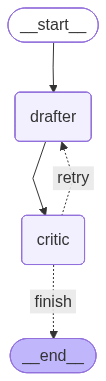

In [58]:
workflow = builder.compile()
workflow

In [59]:
result = workflow.invoke({"topic": "Agentic Workflows in 2026", "draft_history": [], "critique_history": [], "iterations": 0})

final_draft = result['draft_history'][-1]
print(f"FINAL TITLE: {final_draft.title}")
print(f"FINAL CONTENT:\n{final_draft.content}")
print(f"FINAL SCORE: {result['critique_history'][-1].feedback}/10")

Drafting.....
Critic: Evaluating the draft....
FINAL TITLE: Agentic Workflows in 2026
FINAL CONTENT:
<p>The field of artificial intelligence (AI) is rapidly evolving, and one area that stands to revolutionize the way we work is agentic workflows. By combining advanced AI technologies with human expertise, these workflows are designed to automate repetitive tasks, streamline processes, and improve overall productivity. In this draft, we will explore the technical details behind LangGraph, Persistence, and Human-in-the-loop systems, as well as their potential impact on agentic workflows in 2026.</p>

<h1>LangGraph: A Novel Approach to Language Processing</h1>
<p>LangGraph is a cutting-edge technology that utilizes graph-based neural networks (GNNs) to process and understand language data. Unlike traditional approaches, which rely on sequence models, LangGraph can simultaneously consider the relationships between words, phrases, and sentences in a context. This makes it particularly well-

In [61]:
print("="*50)
print(f"🚀 FINAL AGENT REPORT")
print("="*50)

# 1. Show the final polished draft
final_draft = result['draft_history'][-1]
print(f"\n📌 TITLE: {final_draft.title}")
print(f"📝 CONTENT:\n{final_draft.content}")

print("\n" + "-"*30)

# 2. Show the evolution (The "Why")
print(f"📊 PERFORMANCE METRICS:")
print(f"   - Iterations taken: {result['iterations']}")
print(f"   - Final Quality Score: {result['critique_history'][-1].feedback}/10")
print(f"   - Improvements applied: {', '.join(result['critique_history'][-1].improvements)}")

print("="*50)

🚀 FINAL AGENT REPORT

📌 TITLE: Agentic Workflows in 2026
📝 CONTENT:
<p>The field of artificial intelligence (AI) is rapidly evolving, and one area that stands to revolutionize the way we work is agentic workflows. By combining advanced AI technologies with human expertise, these workflows are designed to automate repetitive tasks, streamline processes, and improve overall productivity. In this draft, we will explore the technical details behind LangGraph, Persistence, and Human-in-the-loop systems, as well as their potential impact on agentic workflows in 2026.</p>

<h1>LangGraph: A Novel Approach to Language Processing</h1>
<p>LangGraph is a cutting-edge technology that utilizes graph-based neural networks (GNNs) to process and understand language data. Unlike traditional approaches, which rely on sequence models, LangGraph can simultaneously consider the relationships between words, phrases, and sentences in a context. This makes it particularly well-suited for tasks such as natural 